# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [ ]:
import pandas as pd

df_freq = pd.read_csv("frequencias_aminoacidos.csv", index_col=0)

In [6]:
df_freq 

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
BRCA1,84,44,85,198,49,87,49,77,137,156,30,121,96,97,76,224,111,101,10,31
CDKN2A,29,1,11,11,1,14,5,3,0,17,5,4,11,1,17,7,5,10,2,2
TP53,24,10,20,30,11,23,12,8,20,32,12,14,45,15,26,38,22,18,4,9
KRAS,9,4,16,13,6,12,4,12,21,11,6,4,4,9,10,10,13,16,0,8
SMAD4,48,14,26,25,13,40,30,29,20,41,10,19,45,32,24,45,32,33,8,18


In [12]:
def tendencia_central(vetor):
    media = vetor.mean()
    mediana = vetor.median()
    moda = vetor.mode()
    
    print(f"Média: {media}")
    print(f"Mediana: {mediana}")
    print(f"Moda: {moda.values}")
    
    return None

In [13]:
print("Serina (todos os genes):")
tendencia_central(df_freq["S"])

Serina (todos os genes):
Média: 64.8
Mediana: 38.0
Moda: [  7  10  38  45 224]


In [14]:
nome_terceiro = df_freq.index[2]

print(f"\nTerceiro gene: {nome_terceiro}")

tendencia_central(pd.Series([df_freq.iloc[2]["S"]]))


Terceiro gene: TP53
Média: 38.0
Mediana: 38.0
Moda: [38]


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [8]:
def amplitude(vetor):
    amp = vetor.max() - vetor.min()
    print(f"Amplitude: {amp}")
    return None

In [10]:
print("\nAmplitude de Isoleucina (todos os genes):")
amplitude(df_freq["I"])


Amplitude de Isoleucina (todos os genes):
Amplitude: 74


In [11]:
ultimo_gene_nome = df_freq.index[-1]

print(f"Último gene: {ultimo_gene_nome}")
amplitude(df_freq.iloc[-1])

Último gene: SMAD4
Amplitude: 40


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [15]:
def quartis(vetor):
    q1 = vetor.quantile(0.25)
    q2 = vetor.quantile(0.50)  # mediana
    q3 = vetor.quantile(0.75)
    
    print(f"Q1: {q1}")
    print(f"Q2 (mediana): {q2}")
    print(f"Q3: {q3}")
    
    return None

In [16]:
print("Metionina (M):")
quartis(df_freq["M"])

Metionina (M):
Q1: 6.0
Q2 (mediana): 10.0
Q3: 12.0


In [17]:
nome_primeiro = df_freq.index[0]

print(f"\nPrimeiro gene: {nome_primeiro}")
quartis(df_freq.iloc[0])


Primeiro gene: BRCA1
Q1: 49.0
Q2 (mediana): 86.0
Q3: 113.5


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [18]:
def intervalo_interquartil(vetor):
    q1 = vetor.quantile(0.25)
    q3 = vetor.quantile(0.75)
    iqr = q3 - q1
    
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    
    return None

In [19]:
print("Ácido Glutâmico (E):")
intervalo_interquartil(df_freq["E"])

Ácido Glutâmico (E):
Q1: 13.0
Q3: 30.0
IQR: 17.0


In [20]:
nome_penultimo = df_freq.index[-2]

print(f"\nPenúltimo gene: {nome_penultimo}")
intervalo_interquartil(df_freq.iloc[-2])


Penúltimo gene: KRAS
Q1: 5.5
Q3: 12.25
IQR: 6.75


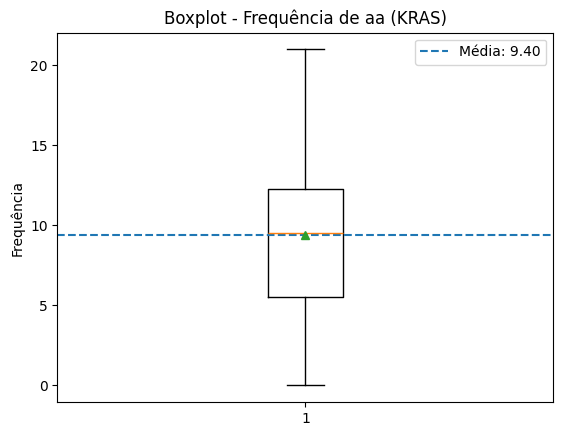

In [21]:
import matplotlib.pyplot as plt

dados = df_freq.iloc[-2]

media = dados.mean()
mediana = dados.median()

plt.figure()
plt.boxplot(dados, vert=True, showmeans=True)

plt.axhline(media, linestyle='--', label=f"Média: {media:.2f}")

plt.title(f"Boxplot - Frequência de aa ({nome_penultimo})")
plt.ylabel("Frequência")
plt.legend()

plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [22]:
def variancia_amostral(vetor):
    var = vetor.var(ddof=1)
    
    print(f"Variância amostral: {var}")
    
    return None

In [23]:
print("Prolina (P):")
variancia_amostral(df_freq["P"])

Prolina (P):
Variância amostral: 1330.7


In [24]:
nome_terceiro = df_freq.index[2]

print(f"\nTerceiro gene: {nome_terceiro}")
variancia_amostral(df_freq.iloc[2])


Terceiro gene: TP53
Variância amostral: 113.18684210526317


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [25]:
def desvio_padrao(vetor):
    dp = vetor.std(ddof=1)
    
    print(f"Desvio padrão: {dp}")
    
    return None

In [26]:
print("Triptofano (W):")
desvio_padrao(df_freq["W"])

Triptofano (W):
Desvio padrão: 4.147288270665545


In [27]:
nome_ultimo = df_freq.index[-1]

print(f"\nGene (index -1): {nome_ultimo}")
desvio_padrao(df_freq.iloc[-1])


Gene (index -1): SMAD4
Desvio padrão: 12.071715528021429


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [28]:
def coeficiente_variacao(vetor):
    media = vetor.mean()
    desvio = vetor.std(ddof=1)
    
    if media == 0:
        print("Coeficiente de variação indefinido (média = 0)")
    else:
        cv = desvio / media
        print(f"Coeficiente de variação: {cv}")
    
    return None

In [29]:
print("Leucina (L):")
coeficiente_variacao(df_freq["L"])

Leucina (L):
Coeficiente de variação: 1.1608608854757907


In [30]:
nome_gene = df_freq.index[1]

print(f"\nGene (index 1): {nome_gene}")
coeficiente_variacao(df_freq.iloc[1])


Gene (index 1): CDKN2A
Coeficiente de variação: 0.9399050865277202


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [31]:
def medidas_resumo(vetor):
    resumo = {
        "média": vetor.mean(),
        "mediana": vetor.median(),
        "moda": vetor.mode().values,
        "mínimo": vetor.min(),
        "máximo": vetor.max(),
        "amplitude": vetor.max() - vetor.min(),
        "Q1": vetor.quantile(0.25),
        "Q2": vetor.quantile(0.50),
        "Q3": vetor.quantile(0.75),
        "IQR": vetor.quantile(0.75) - vetor.quantile(0.25),
        "variância": vetor.var(ddof=1),
        "desvio padrão": vetor.std(ddof=1),
        "coeficiente de variação": vetor.std(ddof=1) / vetor.mean() if vetor.mean() != 0 else None
    }
    
    for chave, valor in resumo.items():
        print(f"{chave}: {valor}")
    
    return None

In [32]:
print("Resumo - Serina (S):")
medidas_resumo(df_freq["S"])

Resumo - Serina (S):
média: 64.8
mediana: 38.0
moda: [  7  10  38  45 224]
mínimo: 7
máximo: 224
amplitude: 217
Q1: 10.0
Q2: 38.0
Q3: 45.0
IQR: 35.0
variância: 8199.699999999999
desvio padrão: 90.5521948933321
coeficiente de variação: 1.397410415020557


In [33]:
nome_gene = df_freq.index[0]

print(f"\nResumo - Gene: {nome_gene}")
medidas_resumo(df_freq.iloc[0])


Resumo - Gene: BRCA1
média: 93.15
mediana: 86.0
moda: [49]
mínimo: 10
máximo: 224
amplitude: 214
Q1: 49.0
Q2: 86.0
Q3: 113.5
IQR: 64.5
variância: 2999.397368421052
desvio padrão: 54.76675422572578
coeficiente de variação: 0.5879415375815972


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [34]:
def maior_cv(df):
    media = df.mean(axis=1)
    desvio = df.std(axis=1, ddof=1)
    
    cv = desvio / media
    
    gene_maior = cv.idxmax()
    valor = cv.max()
    
    print(f"Gene com maior CV: {gene_maior}")
    print(f"Valor do CV: {valor}")
    
    return None

In [35]:
maior_cv(df_freq)

Gene com maior CV: CDKN2A
Valor do CV: 0.9399050865277202


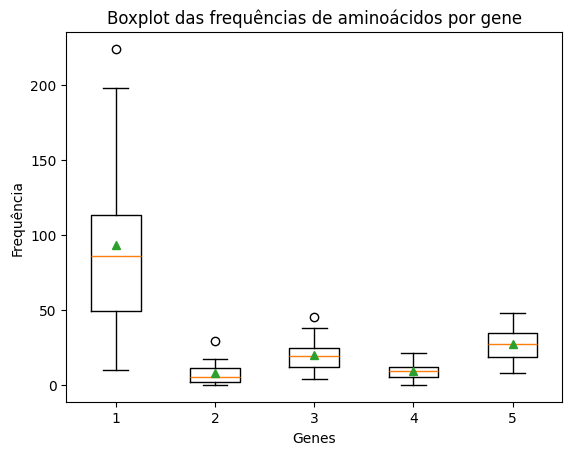

In [37]:
plt.figure()
plt.boxplot(df_freq.T, showmeans=True)

plt.title("Boxplot das frequências de aminoácidos por gene")
plt.xlabel("Genes")
plt.ylabel("Frequência")

plt.show()

Sim, os resultados tendem a concordar. O gene com maior coeficiente de variação apresenta maior dispersão relativa dos dados, o que pode ser observado no boxplot por uma maior amplitude interquartil, maior extensão dos “whiskers” e possível presença de outliers. Isso indica maior variabilidade na frequência dos aminoácidos nesse gene.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [39]:
def maior_cv_aminoacido(df):
    media = df.mean(axis=0)
    desvio = df.std(axis=0, ddof=1)
    
    cv = desvio / media
    
    aa_maior = cv.idxmax()
    valor = cv.max()
    
    print(f"Aminoácido com maior CV: {aa_maior}")
    print(f"Valor do CV: {valor}")
    
    return None

In [40]:
maior_cv_aminoacido(df_freq)

Aminoácido com maior CV: N
Valor do CV: 1.5417585768274988


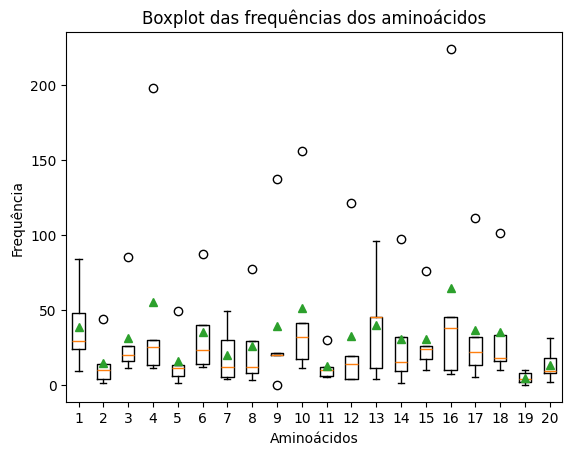

In [41]:
plt.figure()
plt.boxplot(df_freq, showmeans=True)

plt.title("Boxplot das frequências dos aminoácidos")
plt.xlabel("Aminoácidos")
plt.ylabel("Frequência")

plt.show()

Em geral, os resultados tendem a concordar. O aminoácido com maior coeficiente de variação apresenta maior variabilidade relativa entre os genes, o que pode ser observado no boxplot por uma maior dispersão dos dados, evidenciada por caixas mais amplas, maior extensão dos “whiskers” e possível presença de outliers.